# Objectif du notebook 

Date de création : 22/01/2026

Première analyse des données Fiberscope Groix pour la méthode RTF-MFP. 

Analyse des RTFs pour quelques émissions en statique et analyse rapide de la variabilité au sein d'une même séquence. 

In [1]:
import os
import sys
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

In [3]:
sys.path.append(project_root)
from publication.publication_figure import PubFigure, color 
from real_data_analysis.fiberscope_groix.src.fiberscope_groix_manager import (
    FiberscopeManager,
    BandFilter,
)
from propa.rtf.rtf_utils import D_hermitian_angle_fast

In [4]:
# Load GPS dataset for station coordinates
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))

# Load arrivals dataset
fpath = os.path.join(
    data_folder,
    f"processed_arrivals.nc",
)
ds_arr = xr.open_dataset(fpath)
df_arr = ds_arr.to_dataframe()

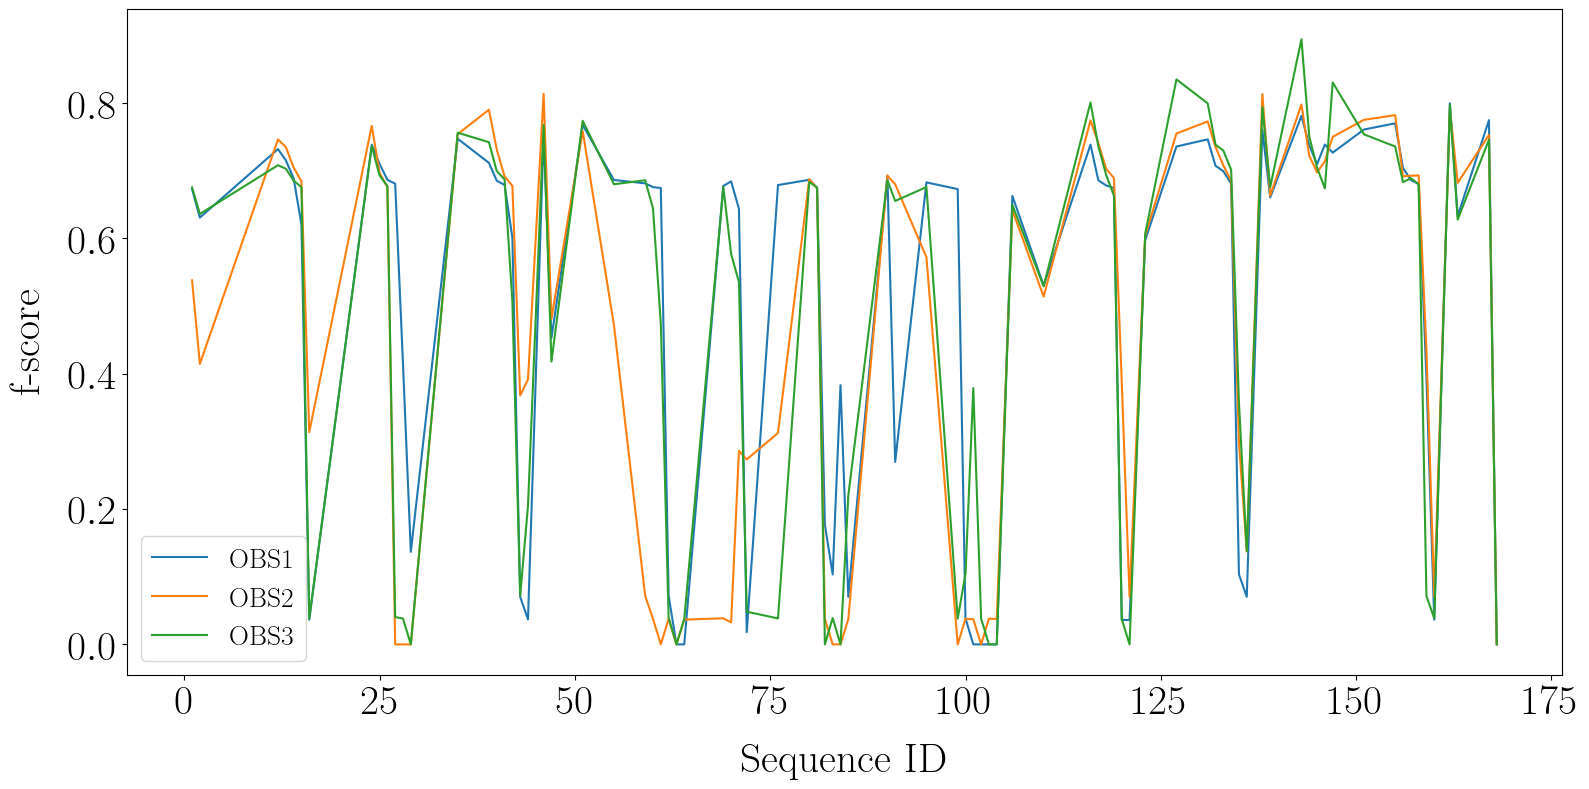

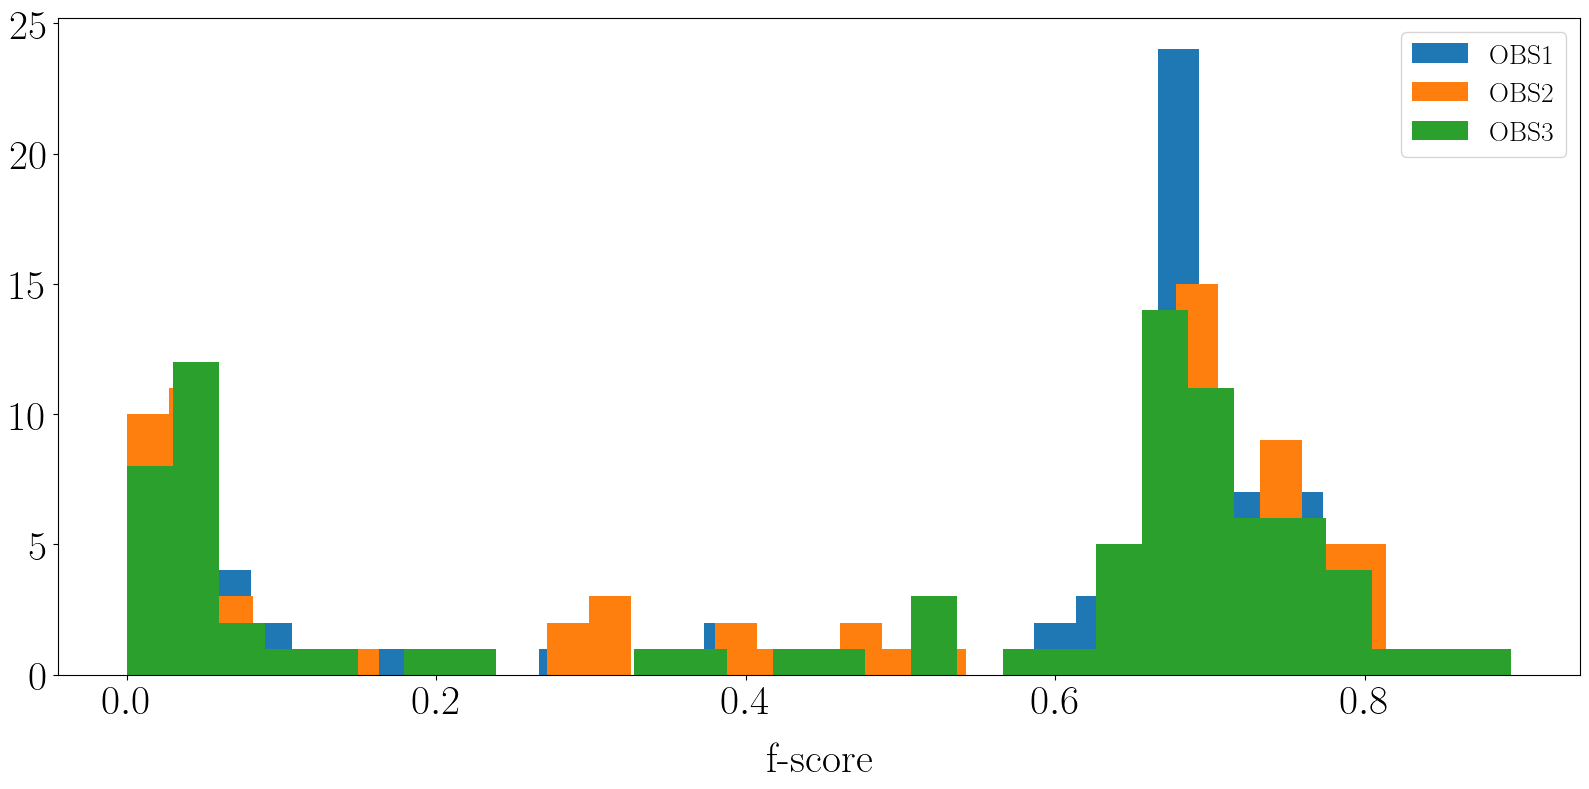

In [5]:
seq_ids = df_arr["sequence_id"].unique()

# Plot f_score for each OBS
plt.figure()
for obs_id in [1, 2, 3]:
    col_name = f"f_score_obs{obs_id}"
    f_score = df_arr.groupby("sequence_id")[col_name].mean()        # Mean over constant array = val (kick trick to compute it)

    # Plot f_score 
    plt.plot(seq_ids, f_score, label=f"OBS{obs_id}")

plt.xlabel("Sequence ID")
plt.ylabel("f-score")
plt.legend()

plt.figure()
for obs_id in [1, 2, 3]:
    col_name = f"f_score_obs{obs_id}"
    f_score = df_arr.groupby("sequence_id")[
        col_name
    ].mean()  # Mean over constant array = val (kick trick to compute it)

    # Plot f_score
    plt.hist(f_score, bins=30, label=f"OBS{obs_id}")

plt.xlabel("f-score")
plt.legend()


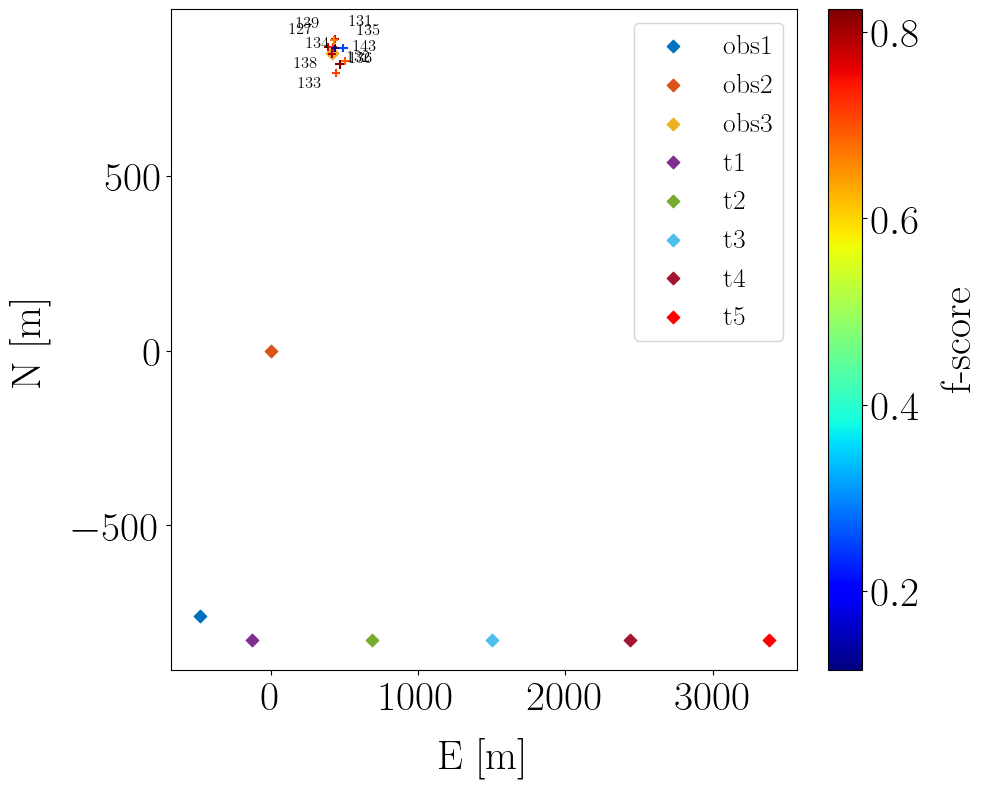

In [6]:
# Tracer des positions d'émission et des positions des OBS sur une carte
df_arr_plot = df_arr.loc[df_arr["src_pos_point"] == "3S"]
sel_sequence_id_to_analyse = df_arr_plot["sequence_id"].unique()
# sel_sequence_id_to_analyse = [117, 121]

seq_e_pos = []
seq_n_pos = []
seq_mean_fscore = []

# Plot
plt.figure(figsize=(10, 8))
for i, seq_id in enumerate(sel_sequence_id_to_analyse):
    df_sequence = df_arr.loc[df_arr["sequence_id"] == seq_id]

    mean_f_score = (
        df_sequence["f_score_obs1"].iloc[0]
        + df_sequence["f_score_obs2"].iloc[0]
        + df_sequence["f_score_obs3"].iloc[0]
    ) / 3
    seq_mean_fscore.append(mean_f_score)
    seq_e_pos.append(df_sequence["emission_interp_e_gps"].iloc[0])
    seq_n_pos.append(df_sequence["emission_interp_n_gps"].iloc[0])

    # plt.scatter(
    #     df_sequence["emission_interp_e_gps"].iloc[0],
    #     df_sequence["emission_interp_n_gps"].iloc[0],
    #     marker="+",
    #     color="k",
    #     # "s",
    #     # label="Sequence emission pos",
    # )

    # Annotate with sequence id
    # Alternate the position of the labels to avoid overlap
    ha = "right" if i % 4 in [0, 3] else "left"
    x_offset = -10 if i % 4 in [0, 3] else 10
    y_offset = 10 if i % 4 in [0, 1] else -10
    plt.annotate(
        seq_id,
        (
            df_sequence["emission_interp_e_gps"].iloc[0],
            df_sequence["emission_interp_n_gps"].iloc[0],
        ),
        textcoords="offset points",
        xytext=(x_offset, y_offset),
        ha=ha,
        fontsize=12,
        # color=mean_f_score,
    )

# Plot emission pos
im = plt.scatter(x=seq_e_pos, y=seq_n_pos, marker="+", c=seq_mean_fscore, cmap="jet")
plt.colorbar(label="f-score")
plt.xlabel("E [m]")
plt.ylabel("N [m]")

keys = ["obs1", "obs2", "obs3", "t1", "t2", "t3", "t4", "t5"]
for ik, k in enumerate(keys):
    e = ds_gps.attrs[f"{k}_e_apriori"]
    n = ds_gps.attrs[f"{k}_n_apriori"]
    plt.scatter(
        e,
        n,
        marker="D",
        label=k,
        zorder=0,
        color=color(ik),
        s=40,
    )


plt.legend()

In [7]:
for i, seq_id in enumerate(sel_sequence_id_to_analyse): 
    print(f'ID {seq_id} -> {seq_mean_fscore[i]}')
# print(sel_sequence_id_to_analyse)
# print(seq_mean_fscore)

ID 127 -> 0.7753801311750643
ID 131 -> 0.7730539820220207
ID 132 -> 0.7270986365372029
ID 133 -> 0.7124835129242392
ID 134 -> 0.689315638146437
ID 135 -> 0.25351332142909944
ID 136 -> 0.11521507597779483
ID 138 -> 0.7894234708343583
ID 139 -> 0.6665577290223461
ID 143 -> 0.8245328448377957


# Étude de la séquence 117 

In [8]:
# seq_id = [117, 127, 131, 132, 133]  # , 134, 135, 136, 143]
# seq_id = [117, 127, 151]  # , 134, 135, 136, 143]
# seq_id = [116, 117, 118, 127, 131, 143, 151, 155, 167]  # , 134, 135, 136, 143]

df_seq = df_arr.loc[df_arr["sequence_id"].isin(sel_sequence_id_to_analyse)]
# df_seq.head(25)

# All sequences with valid detections
valid = (
    df_arr["valid_detection_obs1"]
    & df_arr["valid_detection_obs2"]
    & df_arr["valid_detection_obs3"]
)
df_seq = df_seq.copy().loc[valid]

# Sequence with f-score superior to 0.6
f_score_min = 0.6
mean_fscore = (
    df_seq["f_score_obs1"]
    + df_seq["f_score_obs2"]
    + df_seq["f_score_obs3"]
) / 3
df_seq = df_seq.loc[mean_fscore >= f_score_min]

In [9]:
# Load wav data from netcdf
nc_fpath = os.path.join(data_folder, "channel_H_wav.nc")
ds_wav = xr.open_dataset(nc_fpath)

datetime_fmt = ds_wav.attrs["datetime_format"]
fs = ds_wav.attrs[f"fs_obs{1}"]
ts = 1/fs

In [10]:
# Select window size to compute RTF 
tau_ir_sim = 0.01       # Estimated impulse response duration (-30dB) on profile p1
tau_rtf_analysis = 10 * tau_ir_sim  # To ensure we include the entire response 

# Number of samples corresponding to the assumed impulse response duration
n_rtf_analysis = int(
    tau_rtf_analysis * fs
)  
# Get closer power of 2
nperseg = 2 ** int(
    np.log2(n_rtf_analysis) + 1
)  # Number of sample per snapshot to use = closest power of two
alpha_overlap = 0.5
noverlap = int(nperseg * alpha_overlap)

print(f"nperseg = {nperseg}, noverlap = {noverlap}")

nperseg = 256, noverlap = 128


In [11]:
bandfilter = BandFilter(
    order=4, 
    lowcut=200,
    highcut=990,
)
# bandfilter = None

h_index_ref = 1 # -> OBS 3 has the higher snr 
# root_rtf_data = os.path.join(data_folder, "rtf")
plot_feature = False
process_pulse_one_by_one = True 

fsm = FiberscopeManager(
    root_processed_data=data_folder,
    h_index_ref=h_index_ref,
    plot_feature=plot_feature,
    bandfilter=bandfilter,
    tau_ir=3,
    process_pulse_one_by_one=process_pulse_one_by_one
)

fsm.process_static_analysis(
    df_arrivals=df_seq,
    set_stft_props=True,
    rtf_estimator="cs-evd",
    verbose=False,
)

Progress: ███████████████████████████████████████████████████████████████████████████████████████............. 87%

c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Progress: ████████████████████████████████████████████████████████████████████████████████████████████████████ 100%

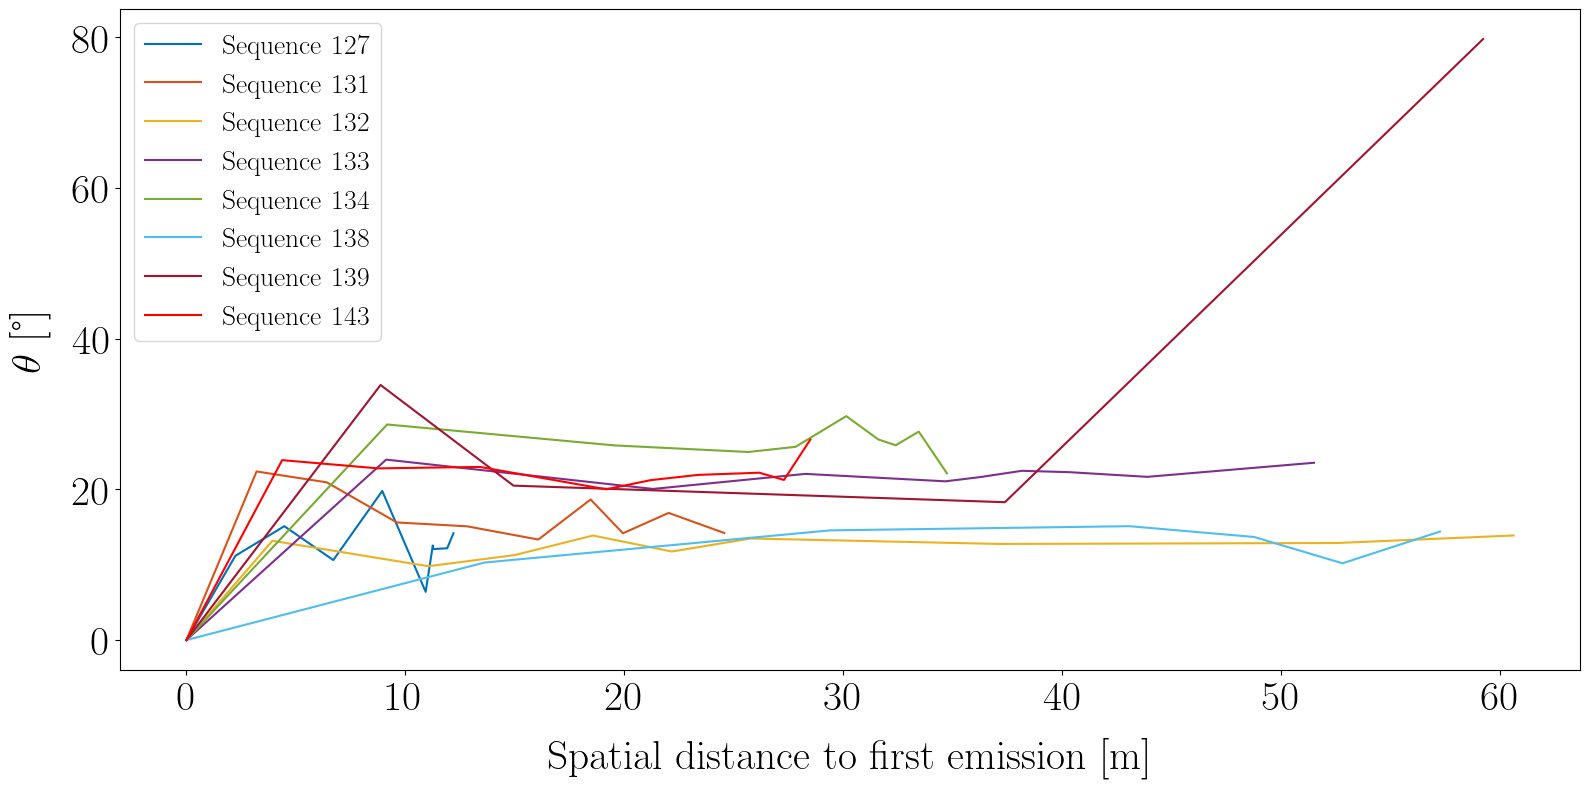

In [12]:
# Analyse rtf variability within a single sequence
fmin = 600
fmax = 800
dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": True}

sigma_theta = []
mean_theta = []
sigma_dist = []
mean_fscore = []
plt.figure()
# plt.title()

sequence_ids = df_seq["sequence_id"].loc[df_seq["src_pos_status"] == "fixed"].unique()

for i, seq_id in enumerate(sequence_ids):
    df_seq_i = df_seq.loc[df_seq["sequence_id"] == seq_id]
    # Load rtf data
    fpath = os.path.join(fsm.root_data_sequence, f"sequence_{seq_id}_rtf.nc")
    xr_seq_i = xr.open_dataset(fpath)
    #

    # -----------------------------------------
    # 1) Evaluate spatial variations
    # -----------------------------------------
    # Emission positions in the sequence
    pos_e_pulse = df_seq_i["emission_interp_e_gps"]
    pos_n_pulse = df_seq_i["emission_interp_n_gps"]

    # Reference pulse = first pulse in sequence
    # TODO we might want to store pos directly in the rtf dataset for simplicity (yet it increases the memory storage)
    ref_pos_e = pos_e_pulse.iloc[0]
    ref_pos_n = pos_n_pulse.iloc[0]

    # Compute distance to all
    spatial_dist = np.sqrt((ref_pos_e - pos_e_pulse)**2 + (ref_pos_n - pos_n_pulse)**2)

    # -----------------------------------------
    # 2) Evaluate RTF variations
    # -----------------------------------------
    # Reference RTF <-> first pulse in sequence
    xr_seq_i_ref = xr_seq_i.isel(pulse_id=0)
    rtf_ref = xr_seq_i_ref.rtf_amp_hat * np.exp(
        1j * xr_seq_i_ref.rtf_phase_hat
    )

    # Rtf for each pulse
    rtf_pulse = xr_seq_i.rtf_amp_hat * np.exp(1j * xr_seq_i.rtf_phase_hat)

    # Limit frequency band
    rtf_ref = rtf_ref.sel(f_rtf=slice(fmin, fmax))
    rtf_pulse = rtf_pulse.sel(f_rtf=slice(fmin, fmax))

    # Compute hermitian angle distance
    theta_dist = []
    for pulse_id in xr_seq_i.pulse_id.values:
        rtf_pulse_i = rtf_pulse.sel(pulse_id=pulse_id)
        theta = D_hermitian_angle_fast(
            rtf_ref=rtf_ref.values, rtf=rtf_pulse_i.values, **dist_kwargs
        )

        theta_dist.append(theta)

    # print(spatial_dist, theta_dist)
    spatial_dist = np.array(spatial_dist)
    theta_dist = np.array(theta_dist)

    # Sort by increasing distance
    dist_to_ref_argsort = np.argsort(spatial_dist)
    sorted_spatial_dist = spatial_dist[dist_to_ref_argsort]
    sorted_theta_dist = theta_dist[dist_to_ref_argsort]

    sigma_dist.append(np.std(sorted_spatial_dist))
    sigma_theta.append(np.std(sorted_theta_dist))
    mean_theta.append(np.mean(sorted_theta_dist))
    mean_f_score = (
        df_seq_i["f_score_obs1"].iloc[0]
        + df_seq_i["f_score_obs2"].iloc[0]
        + df_seq_i["f_score_obs3"].iloc[0]
    ) / 3
    mean_fscore.append(mean_f_score)

    plt.plot(sorted_spatial_dist, sorted_theta_dist, label=f"Sequence {seq_id}", color=color(i))

plt.xlabel('Spatial distance to first emission [m]')
plt.ylabel(r"$\theta$ [°]")
plt.legend()

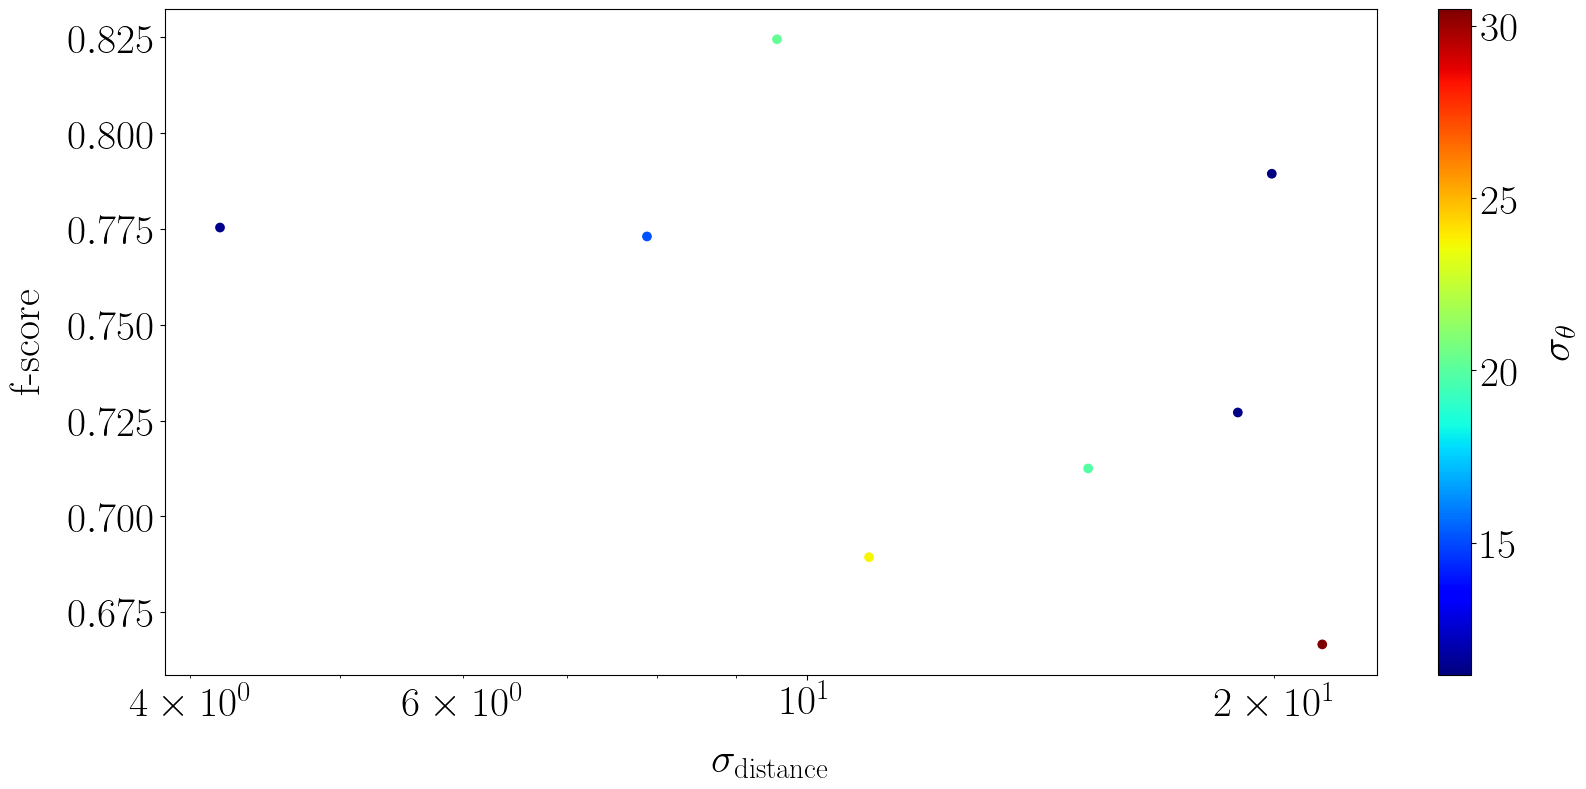

In [13]:
plt.figure()
# plt.scatter(sigma_dist, mean_fscore, c=sigma_theta, cmap="jet")
plt.scatter(sigma_dist, mean_fscore, c=mean_theta, cmap="jet")

plt.xscale("log")
plt.xlabel(r"$\sigma_{\text{distance}}$")
plt.ylabel("f-score")
plt.colorbar(label=r"$\sigma_{\theta}$")

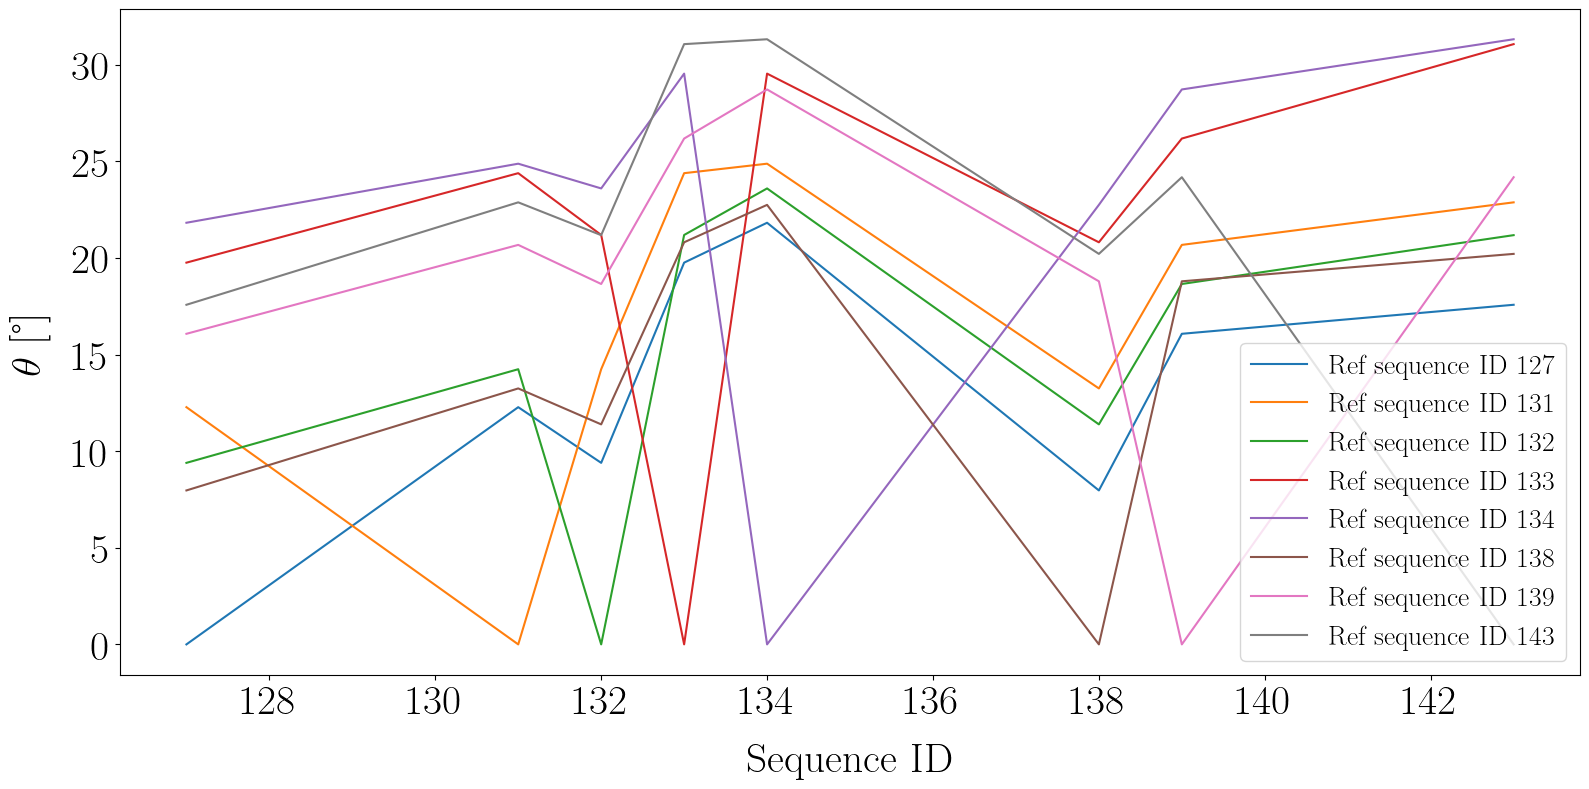

In [14]:
# Analyse rtf variability within a single sequence
fmin = 600
fmax = 800
dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": True}

rtf_seq = []
for seq_id in df_seq["sequence_id"].unique():
    df_seq_i = df_seq.loc[df_seq["sequence_id"] == seq_id]
    # Load rtf data
    fpath = os.path.join(fsm.root_data_sequence, f"sequence_{seq_id}_rtf.nc")
    xr_seq_i = xr.open_dataset(fpath)

    # Store rtf of first emission
    xr_seq_i = xr_seq_i.isel(pulse_id=0)
    rtf = xr_seq_i.rtf_amp_hat * np.exp(1j * xr_seq_i.rtf_phase_hat)

    # Limit frequency band
    rtf = rtf.sel(f_rtf=slice(fmin, fmax))
    # Store
    rtf_seq.append(rtf)

plt.figure()
# plt.title(f"Reference sequence ID {seq_id}")

for i_ref_seq_id, ref_seq_id in enumerate(df_seq["sequence_id"].unique()):
    rtf_ref = rtf_seq[i_ref_seq_id]  # Take sequence id as ref

    # Compute hermitian angle distance
    theta_dist = []
    for i, seq_id in enumerate(df_seq["sequence_id"].unique()):
        rtf_seq_i = rtf_seq[i]
        theta = D_hermitian_angle_fast(
            rtf_ref=rtf_ref.values, rtf=rtf_seq_i.values, **dist_kwargs
        )

        theta_dist.append(theta)

    plt.plot(
        df_seq["sequence_id"].unique(),
        theta_dist,
        label=f"Ref sequence ID {ref_seq_id}",
    )
plt.xlabel("Sequence ID")
plt.ylabel(r"$\theta$ [°]")
plt.legend()

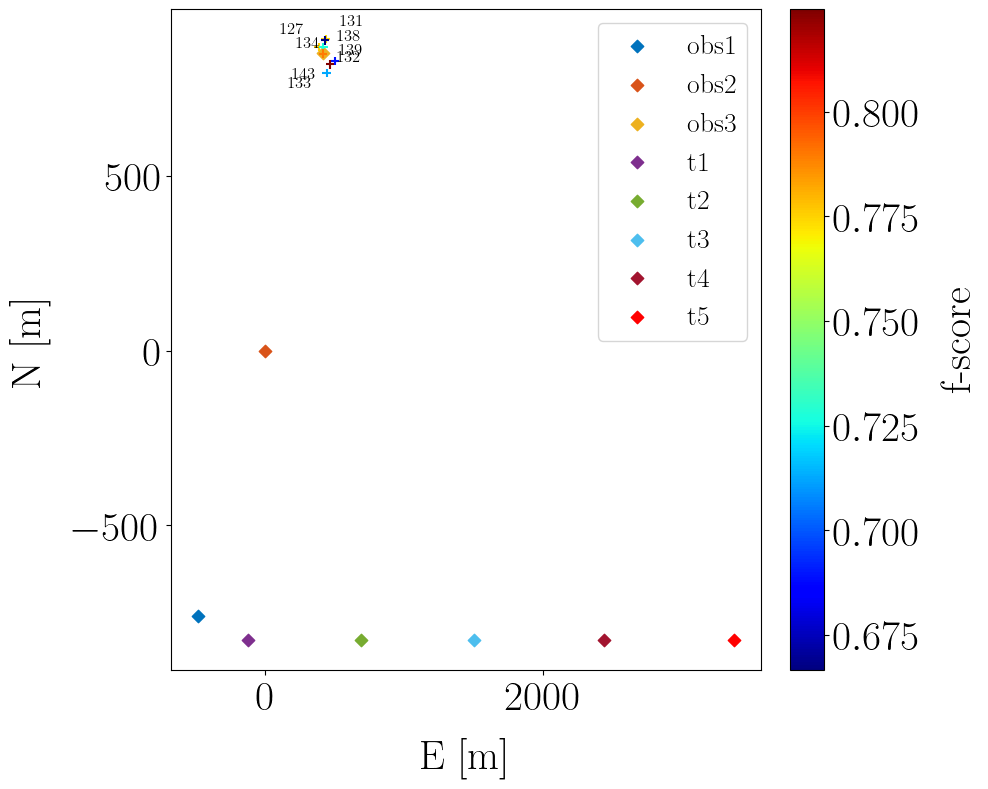

In [15]:
# Tracer des positions d'émission et des positions des OBS sur une carte
sel_sequence_id_to_analyse = df_seq["sequence_id"].unique()

seq_e_pos = []
seq_n_pos = []
seq_mean_fscore = []

# Plot
plt.figure(figsize=(10, 8))
for i, seq_id in enumerate(sel_sequence_id_to_analyse):
    df_sequence = df_arr.loc[df_arr["sequence_id"] == seq_id]

    mean_f_score = (
        df_sequence["f_score_obs1"].iloc[0]
        + df_sequence["f_score_obs2"].iloc[0]
        + df_sequence["f_score_obs3"].iloc[0]
    ) / 3
    seq_mean_fscore.append(mean_f_score)
    seq_e_pos.append(df_sequence["emission_interp_e_gps"].iloc[0])
    seq_n_pos.append(df_sequence["emission_interp_n_gps"].iloc[0])

    # plt.scatter(
    #     df_sequence["emission_interp_e_gps"].iloc[0],
    #     df_sequence["emission_interp_n_gps"].iloc[0],
    #     marker="+",
    #     color="k",
    #     # "s",
    #     # label="Sequence emission pos",
    # )

    # Annotate with sequence id
    # Alternate the position of the labels to avoid overlap
    ha = "right" if i % 4 in [0, 3] else "left"
    x_offset = -10 if i % 4 in [0, 3] else 10
    y_offset = 10 if i % 4 in [0, 1] else -10
    plt.annotate(
        seq_id,
        (
            df_sequence["emission_interp_e_gps"].iloc[0],
            df_sequence["emission_interp_n_gps"].iloc[0],
        ),
        textcoords="offset points",
        xytext=(x_offset, y_offset),
        ha=ha,
        fontsize=12,
        # color=mean_f_score,
    )

# Plot emission pos
im = plt.scatter(x=seq_e_pos, y=seq_n_pos, marker="+", c=seq_mean_fscore, cmap="jet")
plt.colorbar(label="f-score")
plt.xlabel("E [m]")
plt.ylabel("N [m]")

keys = ["obs1", "obs2", "obs3", "t1", "t2", "t3", "t4", "t5"]
for ik, k in enumerate(keys):
    e = ds_gps.attrs[f"{k}_e_apriori"]
    n = ds_gps.attrs[f"{k}_n_apriori"]
    plt.scatter(
        e,
        n,
        marker="D",
        label=k,
        zorder=0,
        color=color(ik),
        s=40,
    )


plt.legend()